In [13]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (CLASS_TO_REGION_DICT,
                                          models_output_dict,
                                          all_regions_list_class)

In [ ]:
# limestone
limestone = ResourceModel(resource_group = 'nmm', resource = 'limestone', 
                       image_mat_available = False, start_year = 1970)

# collect these above defined groups in a dictionary

high = ['class_ 2', 'class_ 20']

low = ['class_ 1']

medium = ['class_ 11' , 'class_ 24',] 

medium_high = ['class_ 23', 'class_ 19']



# trajectory not to forseen, will be fitted with global regression

# what is in rset will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (high+medium+low+medium_high)]

limestone_grouping = {'all' : all_regions_list_class[:-1],
                      'high': high,
                      'medium': medium,
                      'medium_high': medium_high,
                      'low': low,
                      }

limestone.data_grouped_regions(regions_grouping = limestone_grouping) 
limestone.sum_IMAGE_drivers_regions(regions_dict=None)

# calculate regressors
limestone.calculate_regressors(limestone.historic_consumption_data)


In [18]:
best_rmse_models = {
    'all': 'gompertz model',
    'high': 'gompertz model',
    'medium': 'gompertz model',
    'low': 'gompertz model',
    'medium_high': 'gompertz model'

}

bounds = {
    'all': ([0, 0, 0], [1, 10, 10]),
    'high': ([0, 0, 0], [10, 10, 10]),
    'medium': ([0, 2, 2], [10, 10, 10]),
    'low': ([0, 0, 0], [10, 10, 10]),
    'medium_high': ([0, 0, 0], [10, 10, 10])}

limestone.fit_models(best_rmse_models, bounds)
limestone.project_on_total(all_regions_list_class[:-1])

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return 

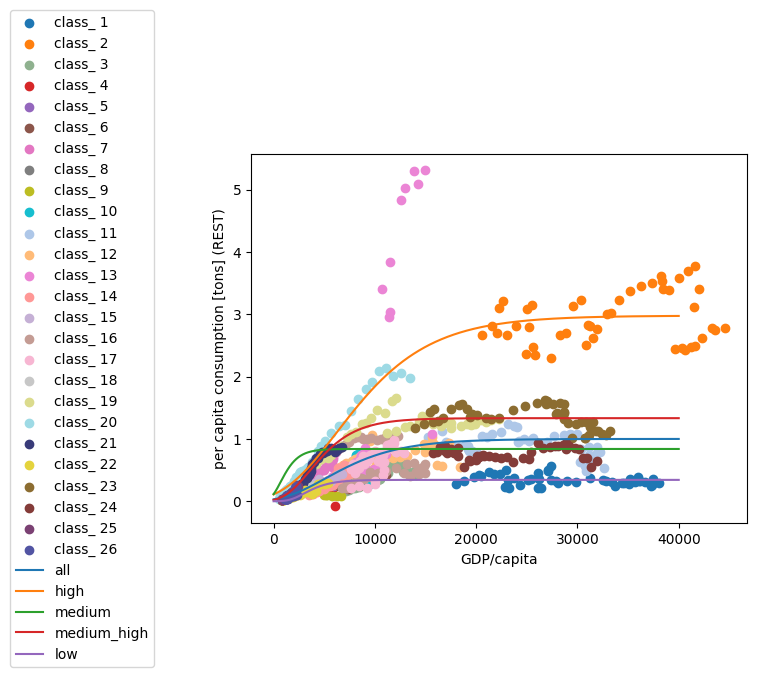

In [16]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', "#8fb18f", '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', "#EB85D5", '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', "#E4D33D", '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in limestone.cons_capita.columns:
    ax.scatter(limestone.gdp_pc[region], 
               limestone.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in limestone_grouping.keys():
    model = limestone.model_groups[grouping][models_output_dict[limestone.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1).astype(float)),
            label = grouping)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


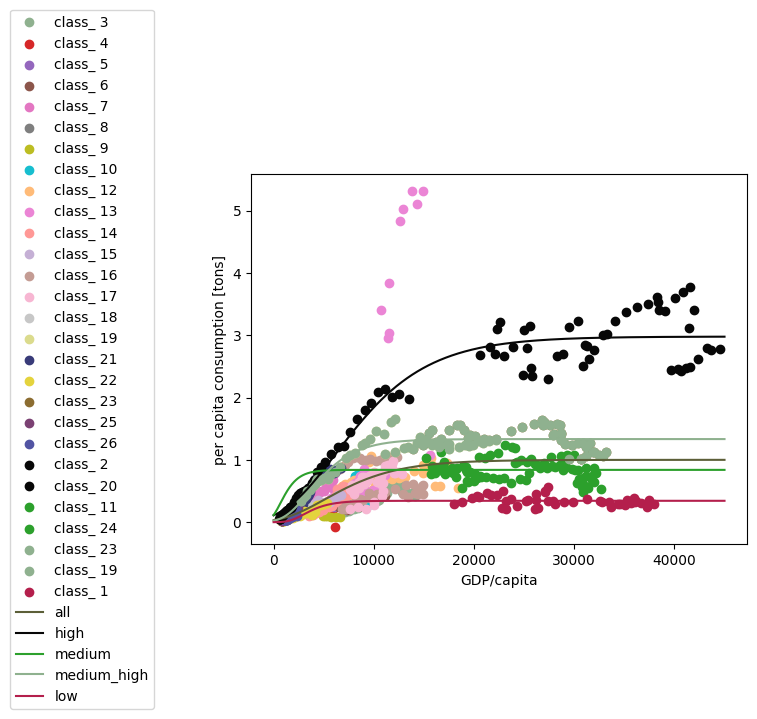

In [17]:
color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_medium = '#2ca02c'
color_medium_high = '#8fb18f'

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'low': color_low,
    'medium': color_medium,
    'high': color_high,
    'medium_high': color_medium_high,
    'all': "#5c5f38",  # Color for all region
}

fig, ax = plt.subplots() 

for region in rest:
    ax.scatter(limestone.gdp_pc[region], 
               limestone.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for region in high:
    ax.scatter(limestone.gdp_pc[region], 
               limestone.cons_capita[region], 
               label = region,
               color = color_dict_fits['high'])
    
for region in medium:
    ax.scatter(limestone.gdp_pc[region], 
               limestone.cons_capita[region], 
               label = region,
               color = color_dict_fits['medium'])
    
for region in medium_high:
    ax.scatter(limestone.gdp_pc[region], 
               limestone.cons_capita[region], 
               label = region,
               color = color_dict_fits['medium_high'])
    
for region in low:
    ax.scatter(limestone.gdp_pc[region], 
               limestone.cons_capita[region], 
               label = region,
               color = color_dict_fits['low'])

for grouping in limestone_grouping.keys():
    model = limestone.model_groups[grouping][models_output_dict[limestone.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1).astype(float)),
            label = grouping,
            color = color_dict_fits[grouping])
    

ax.set_ylabel("per capita consumption [tons]")
ax.set_xlabel("GDP/capita")
plt.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))